In [1]:
import pandas as pd



In [2]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

In [3]:
from sklearn.ensemble import RandomForestRegressor


In [4]:
from sklearn.linear_model import LinearRegression



In [5]:
from sklearn.ensemble import GradientBoostingRegressor

In [6]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

df = pd.read_csv("kenya_motor_insurance_dataset.csv")

X = df.drop(
    columns=["policy_id","premium_amount"]
)

y = df["premium_amount"]

categorical_cols = X.select_dtypes(
    include=["object"]
).columns

numeric_cols = X.select_dtypes(
    exclude=["object"]
).columns

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        ),
        (
            "num",
            "passthrough",
            numeric_cols
        )
    ]
)

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

pipeline.fit(X_train,y_train)

predictions = pipeline.predict(X_test)

mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = mean_squared_error(
    y_test,
    predictions
) ** 0.5

r2 = r2_score(
    y_test,
    predictions
)

In [7]:
print("MAE:",mae)
print("RMSE:",rmse)
print("R2:",r2)

MAE: 1406.8289158625016
RMSE: 1797.7297012268043
R2: 0.9982142133095491


In [8]:
import joblib

joblib.dump(
    pipeline,
    "premium_model.pkl"
)

print("Model Saved")

Model Saved


In [9]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

df = pd.read_csv("kenya_motor_insurance_dataset.csv")

X = df.drop(columns=["policy_id", "premium_amount"])
y = df["premium_amount"]

categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(exclude=["object"]).columns

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("num", "passthrough", numeric_cols)
])

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

pipeline.fit(X_train, y_train)

predictions = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = mean_squared_error(y_test, predictions) ** 0.5
r2 = r2_score(y_test, predictions)

print("Linear Regression")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

Linear Regression
MAE: 592.3732484747742
RMSE: 742.5901496523799
R2: 0.9996952952933795


In [10]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

df = pd.read_csv("kenya_motor_insurance_dataset.csv")

X = df.drop(columns=["policy_id", "premium_amount"])
y = df["premium_amount"]

categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(exclude=["object"]).columns

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("num", "passthrough", numeric_cols)
])

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    ))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

pipeline.fit(X_train, y_train)

predictions = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = mean_squared_error(y_test, predictions) ** 0.5
r2 = r2_score(y_test, predictions)

print("Gradient Boosting")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

Gradient Boosting
MAE: 884.8472970961152
RMSE: 1136.1994282243343
R2: 0.9992866709230596


In [11]:
rf_mae = 1406.8289158625016
rf_rmse = 1797.7297012268043
rf_r2 = 0.9982142133095491

lr_mae = 592.3732484747742
lr_rmse = 742.5901496523799
lr_r2 = 0.9996952952933795

gb_mae = 884.8472970961152
gb_rmse = 1136.1994282243343
gb_r2 = 0.9992866709230596

In [14]:
results = {
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        lr_mae,
        rf_mae,
        gb_mae
    ],
    "RMSE": [
        lr_rmse,
        rf_rmse,
        gb_rmse
    ],
    "R2 Score": [
        lr_r2,
        rf_r2,
        gb_r2
    ]
}

comparison = pd.DataFrame(results)

print(comparison)

comparison.to_csv(
    "model_comparison.csv",
    index=False
)

               Model          MAE         RMSE  R2 Score
0  Linear Regression   592.373248   742.590150  0.999695
1      Random Forest  1406.828916  1797.729701  0.998214
2  Gradient Boosting   884.847297  1136.199428  0.999287


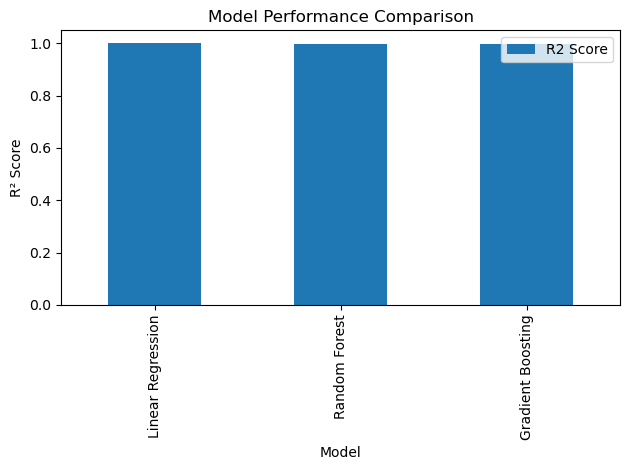

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "R2 Score": [
        0.999695,
        0.998214,
        0.999287
    ]
})

comparison.plot(
    x="Model",
    y="R2 Score",
    kind="bar"
)

plt.title("Model Performance Comparison")
plt.ylabel("R² Score")

plt.tight_layout()
plt.show()

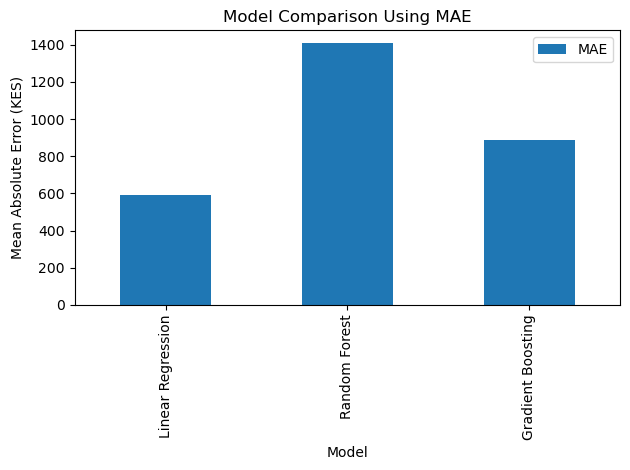

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        592.37,
        1406.83,
        884.85
    ]
})

comparison.plot(
    x="Model",
    y="MAE",
    kind="bar"
)

plt.title("Model Comparison Using MAE")
plt.ylabel("Mean Absolute Error (KES)")
plt.tight_layout()
plt.show()

In [16]:
import joblib

joblib.dump(
    pipeline,
    "premium_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!
